# Comparision of different PRNGs (Model 3)

The Python code in this notebook will load the simulation results stored in the `statistics` folder and will generate the boxplots for model 3 shown in the report.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

plt.style.use('seaborn-v0_8')

## Load and process data

In [2]:
df_a = pd.read_csv("statistics/results3a.txt", header=None, names=["rng_mode", "mean", "a", "b", "n", "time"], sep="\t")
df_b = pd.read_csv("statistics/results3b.txt", header=None, names=["rng_mode", "mean", "a", "b", "n", "EW1", "EW2", "EV1", "EV2", "ENQ1", "ENQ2", "EN1", "EN2", "time"], sep="\t")

In [3]:
generators=df_a["rng_mode"].drop_duplicates().tolist()

### Colors for generator types

In [4]:
def color_from_name(name):
    if name in ['SecureRandom', 'ISAAC']:
        return 'blue'
    if name in ['Drand48', 'Drand48Mix']:
        return 'red'
    return 'black'

def color_labels(ax):
    for label in ax.get_xticklabels():
        label.set_color(color_from_name(label.get_text()))

def color_boxes(ax):
    for i, generator in enumerate(generators):
        c = color_from_name(generator)
        if c == 'black':
            continue
        ax.axvspan(0.5+i, 1.5+i, facecolor=c, alpha=0.1, edgecolor='none', zorder=-10)

def color_all(fig):
    axes = fig.axes
    for ax in axes:
        color_boxes(ax)
    color_labels(axes[-1])

## Generate boxplots for branching errors

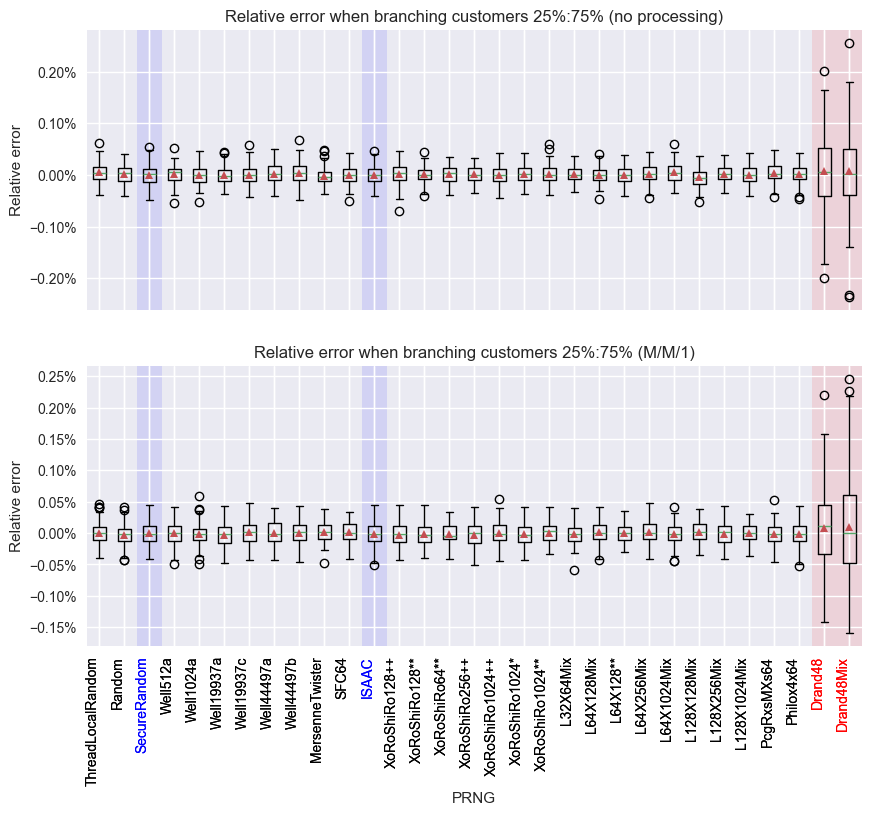

In [ ]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex='col')

ax1.boxplot([(df_a[df_a["rng_mode"] == generator]["a"] - 0.25 * 100_000_000) / (0.25 * 100_000_000) * 100 for generator in generators], showmeans=True)  # type: ignore
ax2.boxplot([(df_b[df_b["rng_mode"] == generator]["a"] - 0.25 * 100_000_000) / (0.25 * 100_000_000) * 100 for generator in generators], showmeans=True)  # type: ignore

ax1.set_title("Relative error when branching customers 25%:75% (no processing)")
ax1.set_ylabel("Relative error")

ax2.set_title("Relative error when branching customers 25%:75% (M/M/1)")
ax2.set_xlabel("PRNG")
ax2.set_ylabel("Relative error")

ax1.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=2))
ax2.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=2))
ax2.set_xticklabels(generators + generators, rotation=90, ha='right')
color_all(fig)

# fig.savefig("PRNG-DES-Benchmarks-Figures-plot3a.pdf", format="pdf", bbox_inches='tight', pad_inches=0)

# fig.savefig("plot3a.png", format="png", bbox_inches='tight', pad_inches=0)

## Generate histograms for $\mathbf{E}[W]$ errors in model 3b

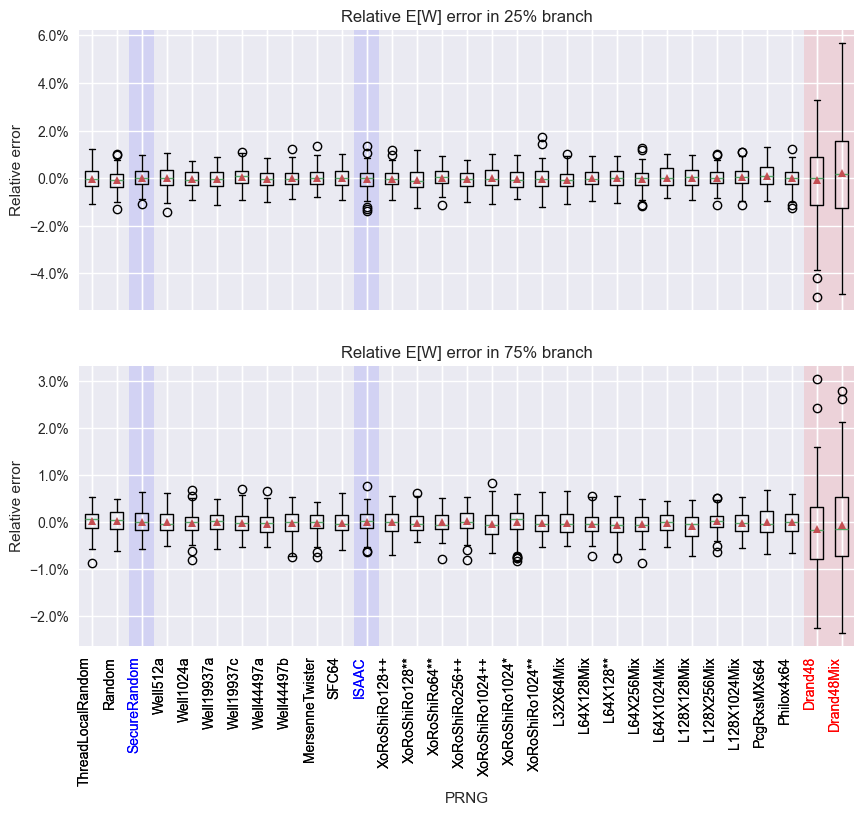

In [ ]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex='col')

ax1.boxplot([(df_b[df_b["rng_mode"] == generator]["EW1"] - 3240) / 3240 * 100 for generator in generators], showmeans=True)  # type: ignore
ax2.boxplot([(df_b[df_b["rng_mode"] == generator]["EW2"] - 1080) / 1080 * 100 for generator in generators], showmeans=True)  # type: ignore

ax1.set_title("Relative E[W] error in 25% branch")
ax1.set_ylabel("Relative error")

ax2.set_title("Relative E[W] error in 75% branch")
ax2.set_xlabel("PRNG")
ax2.set_ylabel("Relative error")

ax1.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=1))
ax2.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=1))
ax2.set_xticklabels(generators + generators, rotation=90, ha='right')
color_all(fig)

# fig.savefig("PRNG-DES-Benchmarks-Figures-plot3b.pdf", format="pdf", bbox_inches='tight', pad_inches=0)

# fig.savefig("plot3b.png", format="png", bbox_inches='tight', pad_inches=0)